# Inteligência Artificial em Jogos 25/26
## Avaliação e Comparação de Performance (Ponto 5)

Neste notebook, vamos carregar os modelos vencedores (Genomas) de ambas as abordagens (Radares e Waypoints) e as respetivas estatísticas. O objetivo é:
1. Comparar as métricas finais (Melhor Fitness, Gerações até à vitória, Tempo de Treino).
2. Visualizar graficamente a topologia das redes neuronais evoluídas.

In [2]:
import pickle
import neat
import matplotlib.pyplot as plt
import os

try:
    import os
    os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

    import visualize
    HAS_VISUALIZE = True
except ImportError:
    HAS_VISUALIZE = False
    print("Aviso: O ficheiro visualize.py não foi encontrado na pasta. Os gráficos das redes não serão gerados.")


try:
    genome_rad
    config_rad
except NameError:
    config_rad = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                             neat.DefaultSpeciesSet, neat.DefaultStagnation, 'configs/config-radares.txt')
    with open('models/stats_radares.pkl', 'rb') as f:
        stats_rad = pickle.load(f)
    with open('models/winner_radares.pkl', 'rb') as f:
        genome_rad = pickle.load(f)

try:
    genome_way
    config_way
except NameError:
    config_way = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                             neat.DefaultSpeciesSet, neat.DefaultStagnation, 'configs/config-waypoints.txt')
    with open('models/stats_waypoints.pkl', 'rb') as f:
        stats_way = pickle.load(f)
    with open('models/winner_waypoints.pkl', 'rb') as f:
        genome_way = pickle.load(f)


### Comparação Direta (Estatísticas de Treino)
Vamos colocar lado a lado o desempenho do treino para perceber qual das abordagens aprendeu a conduzir mais depressa e de forma mais eficiente.

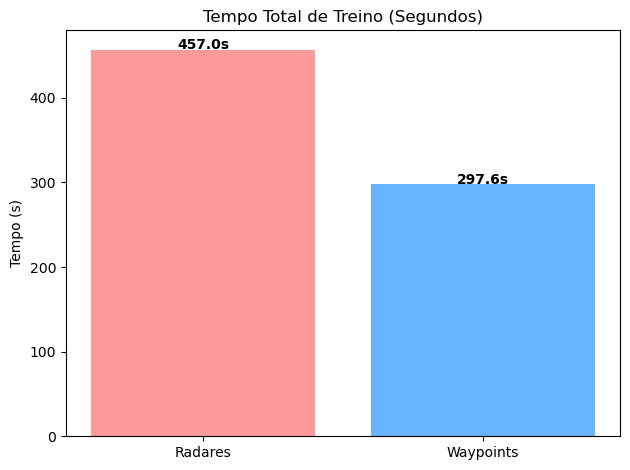

--- ANÁLISE DOS MODELOS VENCEDORES ---
RADARES   | Tamanho da Rede: 2 Nós, 7 Conexões ativas
WAYPOINTS | Tamanho da Rede: 3 Nós, 5 Conexões ativas


In [3]:
labels = ['Radares', 'Waypoints']
tempos = [stats_rad.get('tempo_total', 0), stats_way.get('tempo_total', 0)]


plt.bar(labels, tempos, color=['#ff9999','#66b3ff'])
plt.title('Tempo Total de Treino (Segundos)')
plt.ylabel('Tempo (s)')
for i, v in enumerate(tempos):
    plt.text(i, v + 0.5, f"{v:.1f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("--- ANÁLISE DOS MODELOS VENCEDORES ---")
print(f"RADARES   | Tamanho da Rede: {len(genome_rad.nodes)} Nós, {len(genome_rad.connections)} Conexões ativas")
print(f"WAYPOINTS | Tamanho da Rede: {len(genome_way.nodes)} Nós, {len(genome_way.connections)} Conexões ativas")

### Visualização das Topologias (Redes Neuronais)
Uma das vantagens do algoritmo NEAT é evoluir não só os pesos (como numa rede neuronal fixa), mas também a topologia da rede (adicionando nós e ligações complexas de forma dinâmica). 

Abaixo geramos os diagramas das redes vencedoras para incluirmos no relatório final.

In [4]:
node_names_rad = {-1: 'R_Esq (-60º)', -2: 'R_Esq_C (-30º)', -3: 'R_Frente (0º)', 
                  -4: 'R_Dir_C (+30º)', -5: 'R_Dir (+60º)', 0: 'Acelerar', 1: 'Volante'}
                  
node_names_way = {-1: 'Distância', -2: 'Ângulo', 0: 'Acelerar', 1: 'Volante'}

print("A desenhar as Redes Neuronais para a pasta 'svgs/'...")

try:
    visualize.draw_net(config_rad, genome_rad, view=True, node_names=node_names_rad, filename="svgs/rede_radares_defesa.gv")
    print("Grafo da rede de Radares gerado como 'svgs/rede_radares_defesa.gv.svg'")
    
    nos_ocultos_rad = [node for node in genome_rad.nodes.keys() if node not in config_rad.genome_config.output_keys]
    print(f"   -> Nós Ocultos desenvolvidos (Radares): {len(nos_ocultos_rad)}")
    
except Exception as e:
    print(f"Erro visual (Radares). Verifica se o Graphviz está instalado no SO. Detalhe: {e}")


try:
    visualize.draw_net(config_way, genome_way, view=True, node_names=node_names_way, filename="svgs/rede_waypoints_defesa.gv")
    print("Grafo da rede de Waypoints gerado como 'svgs/rede_waypoints_defesa.gv.svg'")
    
    nos_ocultos_way = [node for node in genome_way.nodes.keys() if node not in config_way.genome_config.output_keys]
    print(f"   -> Nós Ocultos desenvolvidos (Waypoints): {len(nos_ocultos_way)}")
    
except Exception as e:
    print(f"Erro visual (Waypoints). Verifica se o Graphviz está instalado no SO. Detalhe: {e}")

A desenhar as Redes Neuronais para a pasta 'svgs/'...
Grafo da rede de Radares gerado como 'svgs/rede_radares_defesa.gv.svg'
   -> Nós Ocultos desenvolvidos (Radares): 0
Grafo da rede de Waypoints gerado como 'svgs/rede_waypoints_defesa.gv.svg'
   -> Nós Ocultos desenvolvidos (Waypoints): 1


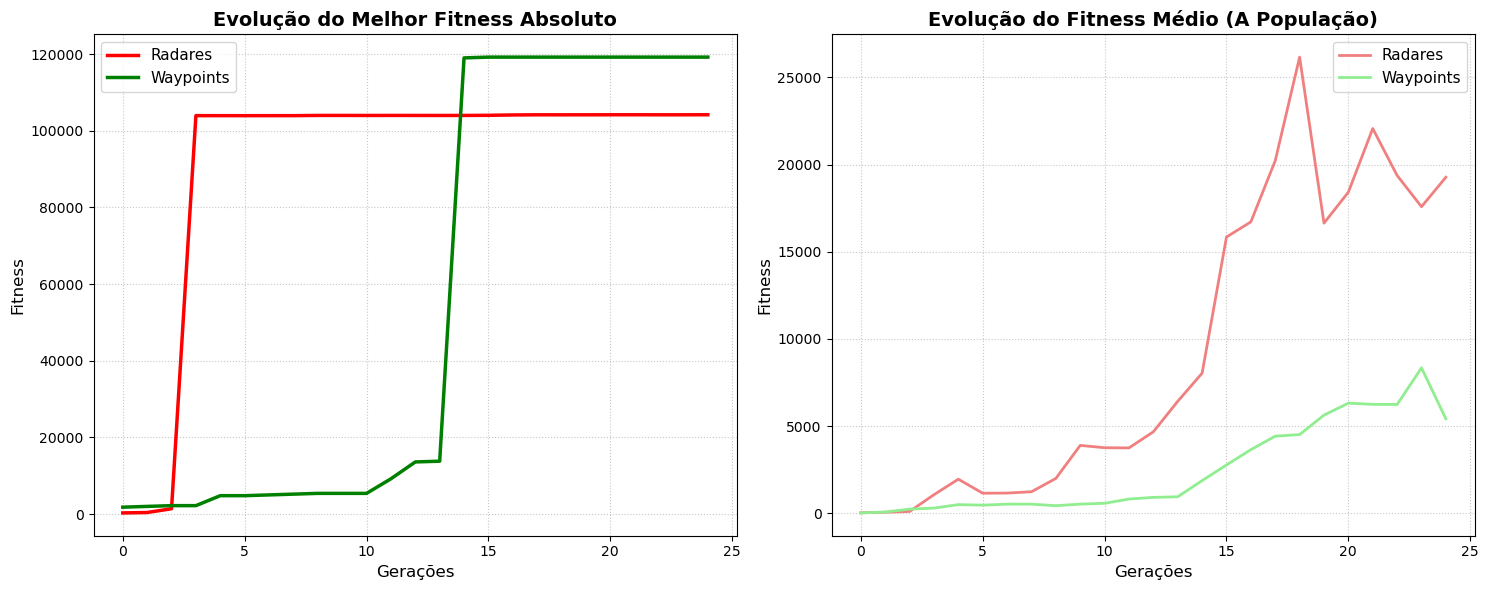

In [4]:
import matplotlib.pyplot as plt

historico_melhor_rad = stats_rad.get('historico_melhor', [])
historico_media_rad = stats_rad.get('historico_media', [])

historico_melhor_way = stats_way.get('historico_melhor', [])
historico_media_way = stats_way.get('historico_media', [])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(historico_melhor_rad, label="Radares", color="red", linewidth=2.5)
ax1.plot(historico_melhor_way, label="Waypoints", color="green", linewidth=2.5)
ax1.set_title("Evolução do Melhor Fitness Absoluto", fontsize=14, fontweight='bold')
ax1.set_xlabel("Gerações", fontsize=12)
ax1.set_ylabel("Fitness", fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.7)

ax2.plot(historico_media_rad, label="Radares", color="lightcoral", linewidth=2)
ax2.plot(historico_media_way, label="Waypoints", color="lightgreen", linewidth=2)
ax2.set_title("Evolução do Fitness Médio (A População)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Gerações", fontsize=12)
ax2.set_ylabel("Fitness", fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()